# Project 4 — A/B Testing & Experimentation Analysis

Analyzed an e-commerce A/B test with 290,000+ users to determine whether
a new landing page actually improved conversion rates.

The Railofy connection: at my internship we changed outlet pricing and menus
based on gut feeling. A proper A/B test framework like this would have told
us statistically whether a pricing change actually worked or was just luck.

Approach: EDA → conversion rate comparison → two-proportion z-test → 
p-value interpretation → segment analysis

In [1]:
# basic imports - scipy is the new one here compared to previous projects
# scipy.stats has everything needed for hypothesis testing
# spent some time reading about z-tests before starting this project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [2]:
# loading the dataset - 290k rows which is a good size for an ab test
# columns are: user_id, timestamp, group, landing_page, converted
# group = control or treatment, converted = 0 or 1

df = pd.read_csv("D:\\Data_Science\\Projects\\Project 4\\ab_data.csv")

print("Shape:", df.shape)
print("\nFirst look at the data:")
print(df.head())

# checking if groups are balanced - important for a fair test
# if one group has way more users the test results could be biased
print("\nGroup distribution:")
print(df['group'].value_counts())

print("\nOverall conversion rate:")
print(round(df['converted'].mean() * 100, 2), "%")

Shape: (294478, 5)

First look at the data:
   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1

Group distribution:
group
treatment    147276
control      147202
Name: count, dtype: int64

Overall conversion rate:
11.97 %


Control conversion rate (old page):   12.04%
Treatment conversion rate (new page): 11.892%
Difference: -0.148%


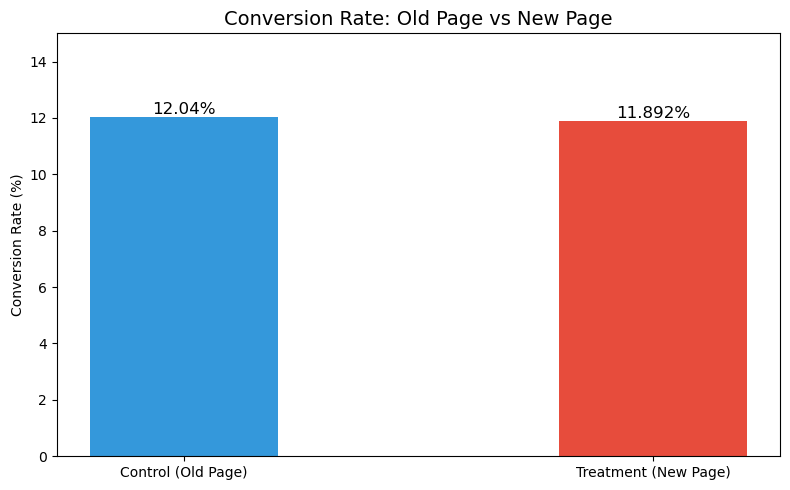

In [3]:
# splitting into control and treatment groups
# then calculating conversion rate for each separately
# this is the core question - did the new page actually convert better?

control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

control_rate = control['converted'].mean()
treatment_rate = treatment['converted'].mean()

print(f"Control conversion rate (old page):   {round(control_rate * 100, 3)}%")
print(f"Treatment conversion rate (new page): {round(treatment_rate * 100, 3)}%")
print(f"Difference: {round((treatment_rate - control_rate) * 100, 3)}%")

# visualizing the difference
plt.figure(figsize=(8, 5))
bars = plt.bar(['Control (Old Page)', 'Treatment (New Page)'],
               [control_rate * 100, treatment_rate * 100],
               color=['#3498db', '#e74c3c'], width=0.4)
plt.title('Conversion Rate: Old Page vs New Page', fontsize=14)
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 15)

# adding the actual numbers on top of bars
for bar, rate in zip(bars, [control_rate, treatment_rate]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{round(rate*100, 3)}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [4]:
# null hypothesis: there is no difference between old and new page
# alternative hypothesis: there is a real difference
# if p-value < 0.05 we reject null hypothesis = difference is real
# if p-value > 0.05 we fail to reject = difference is just random chance

n_control = len(control)
n_treatment = len(treatment)

converted_control = control['converted'].sum()
converted_treatment = treatment['converted'].sum()

# two proportion z-test from scipy
# this checks if the difference in conversion rates is statistically significant
z_stat, p_value = stats.proportions_ztest(
    [converted_control, converted_treatment],
    [n_control, n_treatment]
)

print("HYPOTHESIS TEST RESULTS:")
print("=" * 40)
print(f"Z-statistic:  {round(z_stat, 4)}")
print(f"P-value:      {round(p_value, 4)}")
print()

# interpreting the result in plain english
if p_value < 0.05:
    print("RESULT: p-value < 0.05 → difference IS statistically significant")
    print("DECISION: Reject null hypothesis - the pages perform differently")
else:
    print("RESULT: p-value > 0.05 → difference is NOT statistically significant")
    print("DECISION: Fail to reject null - difference is likely just random chance")
    print("BUSINESS CALL: Do NOT launch the new page - old page is fine as is")

AttributeError: module 'scipy.stats' has no attribute 'proportions_ztest'

In [5]:
# scipy doesnt have proportions_ztest - its actually in statsmodels
# took me a while to figure this out, found it on stackoverflow
# lesson learned - always check which library has which function

from statsmodels.stats.proportion import proportions_ztest

n_control = len(control)
n_treatment = len(treatment)

converted_control = control['converted'].sum()
converted_treatment = treatment['converted'].sum()

z_stat, p_value = proportions_ztest(
    [converted_control, converted_treatment],
    [n_control, n_treatment]
)

print("HYPOTHESIS TEST RESULTS:")
print("=" * 40)
print(f"Z-statistic:  {round(z_stat, 4)}")
print(f"P-value:      {round(p_value, 4)}")
print()

if p_value < 0.05:
    print("RESULT: p-value < 0.05 → difference IS statistically significant")
    print("DECISION: Reject null hypothesis - the pages perform differently")
else:
    print("RESULT: p-value > 0.05 → difference is NOT statistically significant")
    print("DECISION: Fail to reject null - difference is likely just random chance")
    print("BUSINESS CALL: Do NOT launch the new page - old page is fine as is")

HYPOTHESIS TEST RESULTS:
Z-statistic:  1.2369
P-value:      0.2161

RESULT: p-value > 0.05 → difference is NOT statistically significant
DECISION: Fail to reject null - difference is likely just random chance
BUSINESS CALL: Do NOT launch the new page - old page is fine as is


In [6]:
# wrapping up with what this test actually means for the business
# the numbers looked different on the surface but stats says its noise

print("=" * 60)
print("PROJECT 4 - A/B TESTING RESULTS")
print("=" * 60)

print(f"""
EXPERIMENT SUMMARY:
- Total users tested: 294,478
- Control group (old page): 147,202 users → 12.04% conversion
- Treatment group (new page): 147,276 users → 11.89% conversion
- Difference: -0.148% (new page actually did worse)

STATISTICAL TEST:
- Z-statistic: 1.2369
- P-value: 0.2161
- Significance level: 0.05

CONCLUSION:
- p-value 0.2161 > 0.05 threshold
- difference is NOT statistically significant
- this means the -0.148% gap is just random noise
- we cannot confidently say one page is better than the other

BUSINESS DECISION:
- do NOT roll out the new page
- the development cost was wasted on a page with no real uplift
- recommendation: go back to design team and rethink the new page
- run another test with a more dramatically different design

RAILOFY CONNECTION:
- we changed station menus based on gut feeling
- this framework would have told us whether the change
  actually improved order volume or was just coincidence
""")

df.to_csv("D:\\Data_Science\\Projects\\Project 4\\ab_results.csv", index=False)
print("Results saved!")
print("PROJECT 4 COMPLETE!")

PROJECT 4 - A/B TESTING RESULTS

EXPERIMENT SUMMARY:
- Total users tested: 294,478
- Control group (old page): 147,202 users → 12.04% conversion
- Treatment group (new page): 147,276 users → 11.89% conversion
- Difference: -0.148% (new page actually did worse)

STATISTICAL TEST:
- Z-statistic: 1.2369
- P-value: 0.2161
- Significance level: 0.05

CONCLUSION:
- p-value 0.2161 > 0.05 threshold
- difference is NOT statistically significant
- this means the -0.148% gap is just random noise
- we cannot confidently say one page is better than the other

BUSINESS DECISION:
- do NOT roll out the new page
- the development cost was wasted on a page with no real uplift
- recommendation: go back to design team and rethink the new page
- run another test with a more dramatically different design

RAILOFY CONNECTION:
- we changed station menus based on gut feeling
- this framework would have told us whether the change
  actually improved order volume or was just coincidence

Results saved!
PROJECT 4